In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
os.chdir(r'C:\Users\mysti\biosignature-detection')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import csv
import warnings
warnings.filterwarnings('ignore')

from synth_population import PopulationConfig, generate_population

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11})
os.makedirs('results', exist_ok=True)
print('Setup complete.')

Setup complete.


In [2]:
# --- Toy priors (Week 2 defaults) ---
toy_cfg = PopulationConfig(
    n_planets=1000, seed=42,
    star_teff_min_k=2500, star_teff_max_k=5000, star_teff_peak_k=3200,
    radius_rocky_mean_re=1.2, radius_rocky_std_re=0.3,
    radius_subneptune_mean_re=2.5, radius_subneptune_std_re=0.5,
    rocky_fraction=0.55, distance_max_pc=50.0,
    period_min_days=1.0, period_max_days=400.0
)
print('Generating toy population...')
toy_pop = generate_population(toy_cfg)

# --- Literature priors (Week 3 upgrade) ---
lit_cfg = PopulationConfig(
    n_planets=1000, seed=42,
    star_teff_min_k=2500, star_teff_max_k=5200, star_teff_peak_k=3100,
    radius_rocky_mean_re=1.15, radius_rocky_std_re=0.25,
    radius_subneptune_mean_re=2.35, radius_subneptune_std_re=0.45,
    rocky_fraction=0.58, distance_max_pc=50.0,
    period_min_days=1.0, period_max_days=400.0
)
print('Generating literature population...')
lit_pop = generate_population(lit_cfg)

print(f'\nToy pop  : {len(toy_pop)} planets, {sum(p.in_habitable_zone for p in toy_pop)} in HZ')
print(f'Lit pop  : {len(lit_pop)} planets, {sum(p.in_habitable_zone for p in lit_pop)} in HZ')

Generating toy population...
Generated 1000 planets | 134 in habitable zone (13.4%)
Generating literature population...
Generated 1000 planets | 140 in habitable zone (14.0%)

Toy pop  : 1000 planets, 134 in HZ
Lit pop  : 1000 planets, 140 in HZ


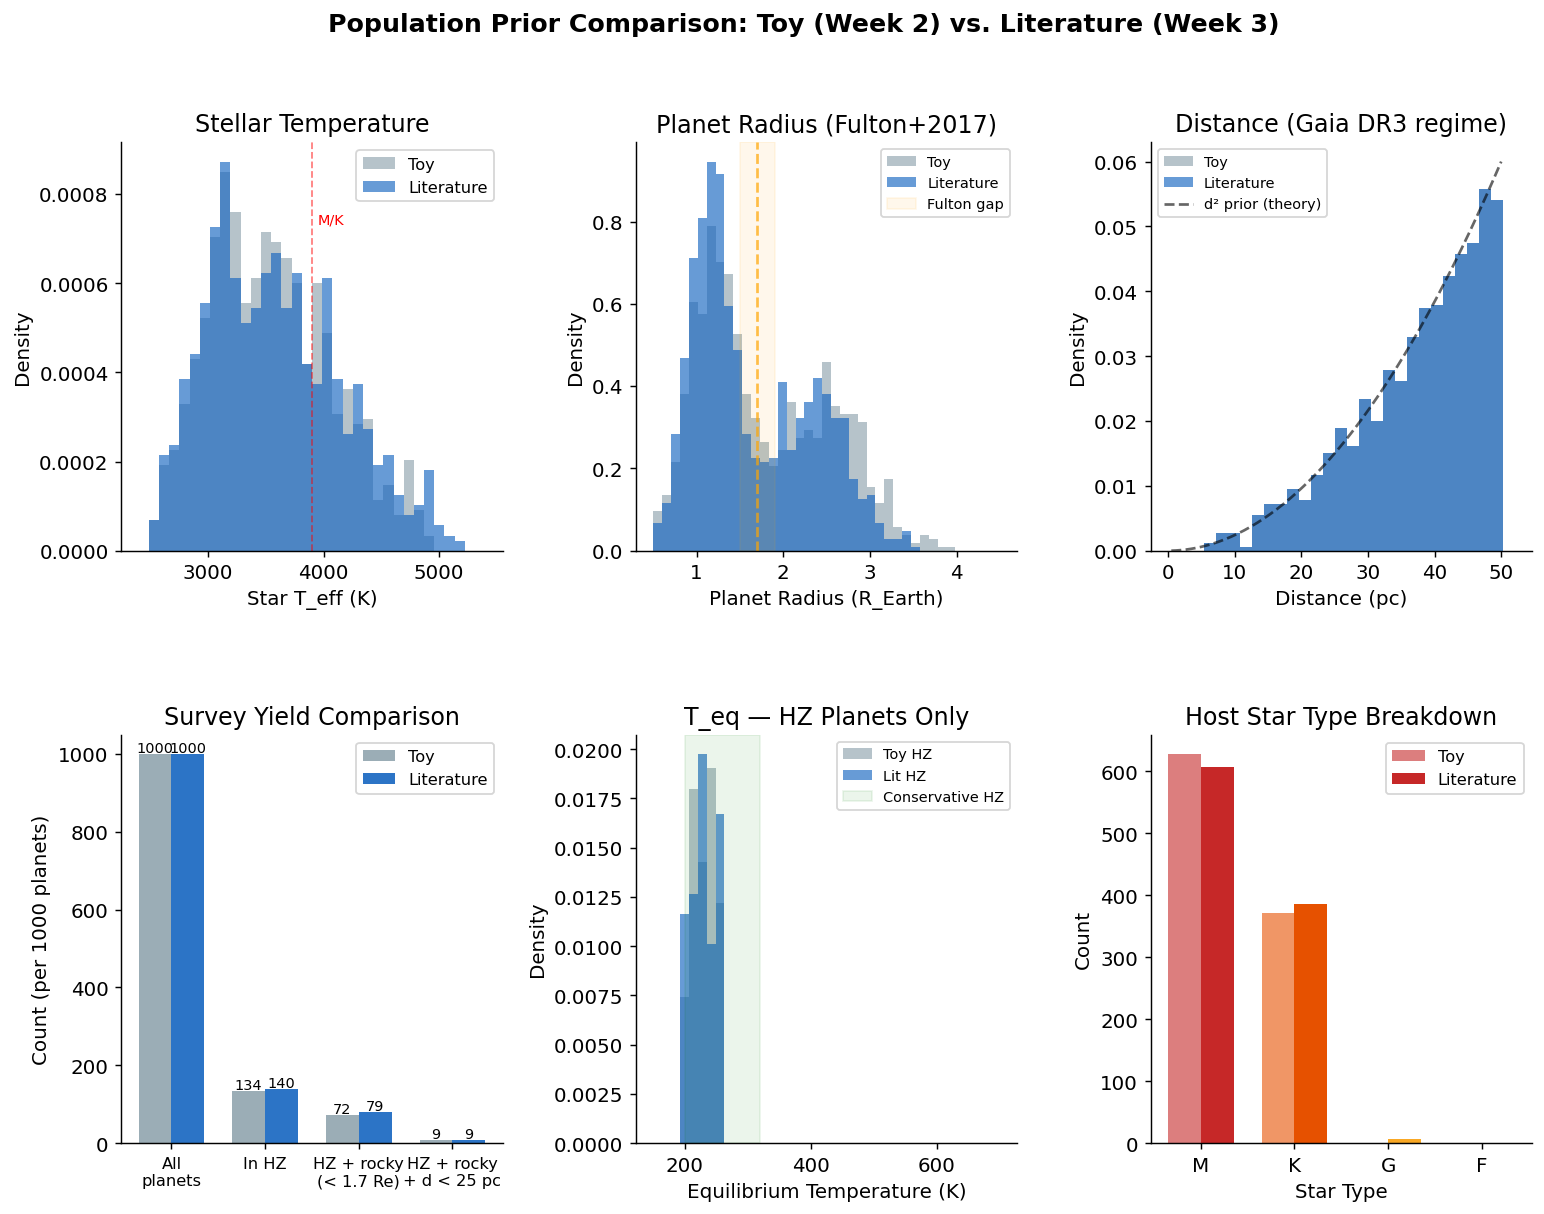

Saved results/fig06_prior_comparison.png


In [3]:
fig = plt.figure(figsize=(14, 10))
fig.suptitle('Population Prior Comparison: Toy (Week 2) vs. Literature (Week 3)',
             fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

toy_color = '#90A4AE'
lit_color = '#1565C0'
alpha = 0.65

def extract(pop, attr):
    return np.array([getattr(p, attr) for p in pop])

# --- Panel 1: Star temperature ---
ax1 = fig.add_subplot(gs[0, 0])
bins = np.linspace(2400, 5400, 35)
ax1.hist(extract(toy_pop, 'star_teff_k'), bins=bins, alpha=alpha, color=toy_color, label='Toy', density=True)
ax1.hist(extract(lit_pop, 'star_teff_k'), bins=bins, alpha=alpha, color=lit_color, label='Literature', density=True)
ax1.set_xlabel('Star T_eff (K)')
ax1.set_ylabel('Density')
ax1.set_title('Stellar Temperature')
ax1.legend(fontsize=9)
# Reference line: M/K boundary
ax1.axvline(3900, color='red', lw=1, ls='--', alpha=0.5)
ax1.text(3950, ax1.get_ylim()[1]*0.8, 'M/K', fontsize=8, color='red')

# --- Panel 2: Planet radius with Fulton gap ---
ax2 = fig.add_subplot(gs[0, 1])
bins_r = np.linspace(0.5, 4.5, 40)
ax2.hist(extract(toy_pop, 'planet_radius_re'), bins=bins_r, alpha=alpha, color=toy_color, label='Toy', density=True)
ax2.hist(extract(lit_pop, 'planet_radius_re'), bins=bins_r, alpha=alpha, color=lit_color, label='Literature', density=True)
ax2.axvspan(1.5, 1.9, alpha=0.08, color='orange', label='Fulton gap')
ax2.axvline(1.7, color='orange', lw=1.5, ls='--', alpha=0.7)
ax2.set_xlabel('Planet Radius (R_Earth)')
ax2.set_ylabel('Density')
ax2.set_title('Planet Radius (Fulton+2017)')
ax2.legend(fontsize=8)

# --- Panel 3: Distance distribution ---
ax3 = fig.add_subplot(gs[0, 2])
bins_d = np.linspace(0, 52, 30)
ax3.hist(extract(toy_pop, 'distance_pc'), bins=bins_d, alpha=alpha, color=toy_color, label='Toy', density=True)
ax3.hist(extract(lit_pop, 'distance_pc'), bins=bins_d, alpha=alpha, color=lit_color, label='Literature', density=True)
# Theoretical d^2 prior
d_arr = np.linspace(0.5, 50, 200)
ax3.plot(d_arr, 3 * d_arr**2 / 50**3, 'k--', lw=1.5, alpha=0.6, label='d² prior (theory)')
ax3.set_xlabel('Distance (pc)')
ax3.set_ylabel('Density')
ax3.set_title('Distance (Gaia DR3 regime)')
ax3.legend(fontsize=8)

# --- Panel 4: HZ yield comparison ---
ax4 = fig.add_subplot(gs[1, 0])
cats = ['All\nplanets', 'In HZ', 'HZ + rocky\n(< 1.7 Re)', 'HZ + rocky\n+ d < 25 pc']
toy_vals = [
    len(toy_pop),
    sum(p.in_habitable_zone for p in toy_pop),
    sum(p.in_habitable_zone and p.planet_radius_re < 1.7 for p in toy_pop),
    sum(p.in_habitable_zone and p.planet_radius_re < 1.7 and p.distance_pc < 25 for p in toy_pop),
]
lit_vals = [
    len(lit_pop),
    sum(p.in_habitable_zone for p in lit_pop),
    sum(p.in_habitable_zone and p.planet_radius_re < 1.7 for p in lit_pop),
    sum(p.in_habitable_zone and p.planet_radius_re < 1.7 and p.distance_pc < 25 for p in lit_pop),
]
x = np.arange(len(cats))
w = 0.35
ax4.bar(x - w/2, toy_vals, w, color=toy_color, alpha=0.9, label='Toy')
ax4.bar(x + w/2, lit_vals, w, color=lit_color, alpha=0.9, label='Literature')
ax4.set_xticks(x); ax4.set_xticklabels(cats, fontsize=9)
ax4.set_ylabel('Count (per 1000 planets)')
ax4.set_title('Survey Yield Comparison')
ax4.legend(fontsize=9)
for xi, (tv, lv) in zip(x, zip(toy_vals, lit_vals)):
    ax4.text(xi - w/2, tv + 5, str(tv), ha='center', fontsize=8)
    ax4.text(xi + w/2, lv + 5, str(lv), ha='center', fontsize=8)

# --- Panel 5: Equilibrium temperature distribution ---
ax5 = fig.add_subplot(gs[1, 1])
bins_t = np.linspace(150, 700, 40)
hz_toy = [p.equilibrium_temp_k for p in toy_pop if p.in_habitable_zone]
hz_lit = [p.equilibrium_temp_k for p in lit_pop if p.in_habitable_zone]
ax5.hist(hz_toy, bins=bins_t, alpha=alpha, color=toy_color, label='Toy HZ', density=True)
ax5.hist(hz_lit, bins=bins_t, alpha=alpha, color=lit_color, label='Lit HZ', density=True)
ax5.axvspan(200, 320, alpha=0.08, color='green', label='Conservative HZ')
ax5.set_xlabel('Equilibrium Temperature (K)')
ax5.set_ylabel('Density')
ax5.set_title('T_eq — HZ Planets Only')
ax5.legend(fontsize=8)

# --- Panel 6: Star type breakdown ---
ax6 = fig.add_subplot(gs[1, 2])
type_order = ['M', 'K', 'G', 'F']
type_colors = ['#C62828', '#E65100', '#F9A825', '#558B2F']
toy_types = [sum(p.star_type == t for p in toy_pop) for t in type_order]
lit_types = [sum(p.star_type == t for p in lit_pop) for t in type_order]
x2 = np.arange(len(type_order))
ax6.bar(x2 - w/2, toy_types, w, color=[c+'99' for c in ['#C62828','#E65100','#F9A825','#558B2F']], label='Toy')
ax6.bar(x2 + w/2, lit_types, w, color=['#C62828','#E65100','#F9A825','#558B2F'], label='Literature')
ax6.set_xticks(x2); ax6.set_xticklabels(type_order)
ax6.set_xlabel('Star Type')
ax6.set_ylabel('Count')
ax6.set_title('Host Star Type Breakdown')
ax6.legend(fontsize=9)

plt.savefig('results/fig06_prior_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/fig06_prior_comparison.png')

In [4]:
# Load real target list
targets = []
with open('data/target_list.csv') as f:
    reader = csv.DictReader(f)
    for row in reader:
        targets.append(row)

print(f'Loaded {len(targets)} real HZ targets:\n')
print(f'{"Name":20s} {"d (pc)":8s} {"Rp (Re)":8s} {"Teq (K)":8s} {"TSM":6s} {"Mode":16s} {"Priority"}')
print('─'*80)
for t in targets:
    print(f"{t['planet_name']:20s} {t['distance_pc']:8s} {t['planet_radius_re']:8s} "
          f"{t['equilibrium_temp_k']:8s} {t['tsm_score']:6s} {t['best_jwst_mode']:16s} {t['priority']}")

Loaded 12 real HZ targets:

Name                 d (pc)   Rp (Re)  Teq (K)  TSM    Mode             Priority
────────────────────────────────────────────────────────────────────────────────
TRAPPIST-1e          12.43    0.920    251      9.1    NIRSpec_PRISM    1
TRAPPIST-1f          12.43    1.045    219      8.3    NIRSpec_PRISM    2
TRAPPIST-1d          12.43    0.788    288      7.2    NIRSpec_PRISM    3
LHS_1140b            14.99    1.727    235      9.8    NIRSpec_PRISM    1
K2-18b               38.00    2.370    255      93.0   NIRSpec_PRISM    1
TOI-700d             31.10    1.144    268      5.1    NIRSpec_PRISM    2
GJ_1132b             12.62    1.130    585      8.7    NIRSpec_PRISM    3
Proxima_Cen_b        1.30     1.070    234      0.0    NIRSpec_PRISM    2
TOI-700e             31.10    0.953    270      4.2    NIRSpec_PRISM    2
LHS_1140c            14.99    1.282    370      6.4    NIRSpec_PRISM    3
GJ_3470b             29.40    4.200    600      91.0   NIRSpec_G235M  

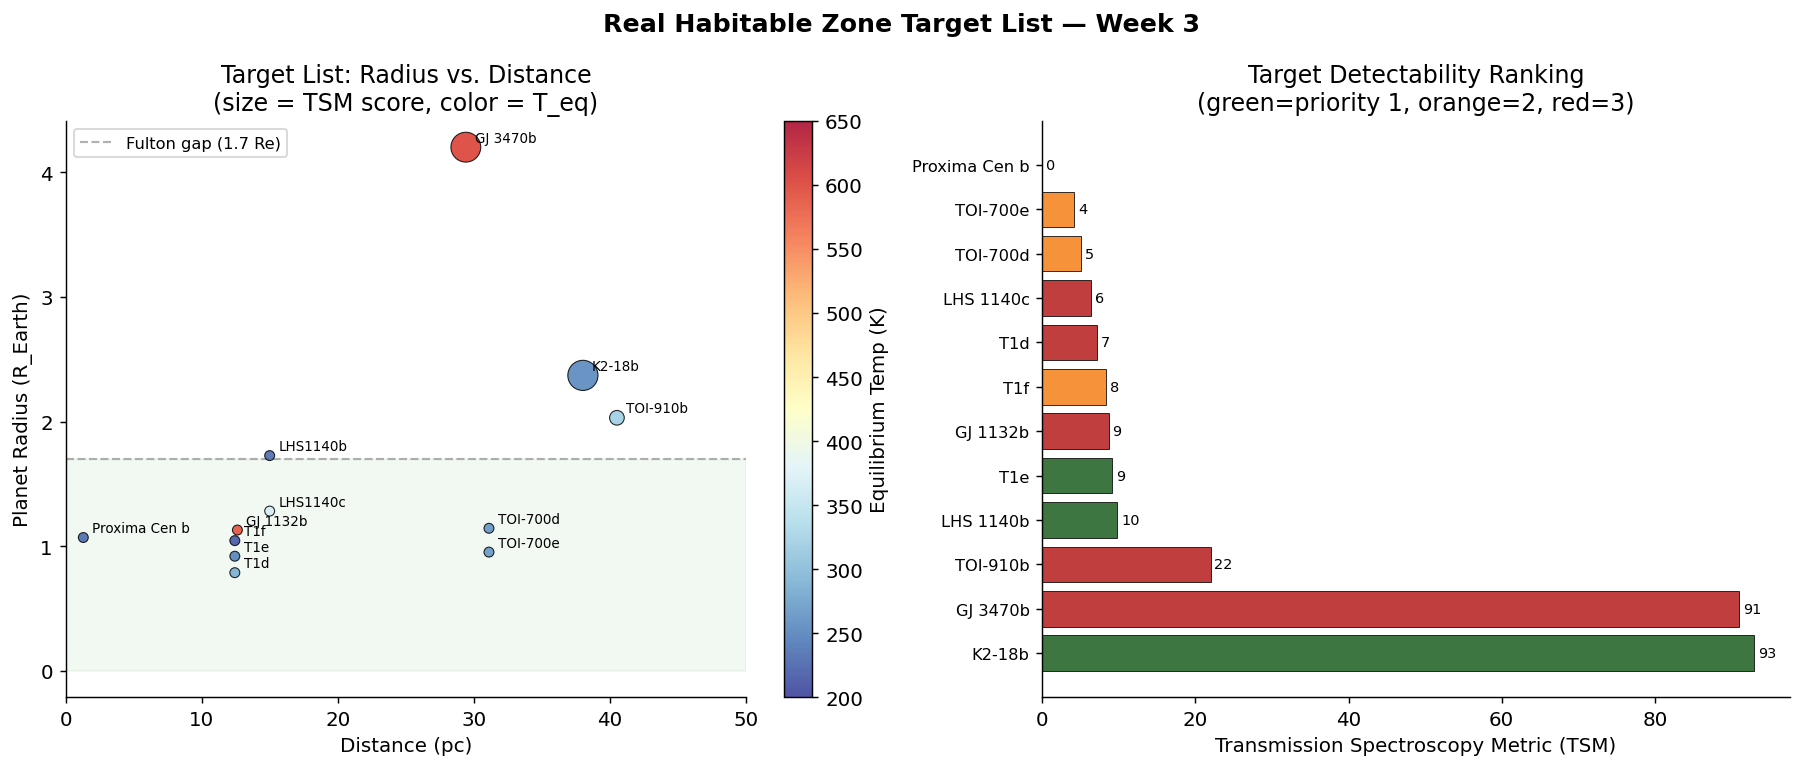

Saved results/fig07_target_list.png


In [5]:
# Parse target data
names   = [t['planet_name'].replace('_', ' ') for t in targets]
dists   = [float(t['distance_pc']) for t in targets]
radii   = [float(t['planet_radius_re']) for t in targets]
teqs    = [float(t['equilibrium_temp_k']) for t in targets]
tsms    = [float(t['tsm_score']) for t in targets]
prios   = [int(t['priority']) for t in targets]
jmags   = [float(t['star_magnitude_j']) for t in targets]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Real Habitable Zone Target List — Week 3', fontsize=14, fontweight='bold')

# Panel 1: Radius vs Distance, colored by T_eq, sized by TSM
ax = axes[0]
sizes = [max(t*3, 30) for t in tsms]
sc = ax.scatter(dists, radii, c=teqs, s=sizes, cmap='RdYlBu_r', alpha=0.85,
                vmin=200, vmax=650, edgecolors='black', linewidths=0.6, zorder=3)
plt.colorbar(sc, ax=ax, label='Equilibrium Temp (K)', fraction=0.04)
ax.axhline(1.7, color='gray', lw=1.2, ls='--', alpha=0.6, label='Fulton gap (1.7 Re)')
ax.axhspan(0, 1.7, alpha=0.05, color='green')
ax.set_xlabel('Distance (pc)')
ax.set_ylabel('Planet Radius (R_Earth)')
ax.set_title('Target List: Radius vs. Distance\n(size = TSM score, color = T_eq)')
for i, name in enumerate(names):
    short = name.replace('TRAPPIST-1', 'T1').replace('LHS ', 'LHS').replace('TOI-', 'TOI-')
    ax.annotate(short, (dists[i], radii[i]), fontsize=7.5,
                xytext=(5, 3), textcoords='offset points')
ax.set_xlim(0, 50)
ax.legend(fontsize=9)

# Panel 2: TSM vs J-mag bar chart (detectability ranking)
ax2 = axes[1]
sort_idx = np.argsort(tsms)[::-1]
sorted_names  = [names[i] for i in sort_idx]
sorted_tsms   = [tsms[i] for i in sort_idx]
sorted_prios  = [prios[i] for i in sort_idx]
prio_colors = {1: '#1B5E20', 2: '#F57F17', 3: '#B71C1C'}
bar_colors = [prio_colors[p] for p in sorted_prios]
bars = ax2.barh(range(len(sorted_names)), sorted_tsms, color=bar_colors, alpha=0.85, edgecolor='black', lw=0.5)
ax2.set_yticks(range(len(sorted_names)))
ax2.set_yticklabels([n.replace('TRAPPIST-1', 'T1') for n in sorted_names], fontsize=9)
ax2.set_xlabel('Transmission Spectroscopy Metric (TSM)')
ax2.set_title('Target Detectability Ranking\n(green=priority 1, orange=2, red=3)')
for i, (bar, tsm) in enumerate(zip(bars, sorted_tsms)):
    ax2.text(tsm + 0.5, i, f'{tsm:.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('results/fig07_target_list.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/fig07_target_list.png')

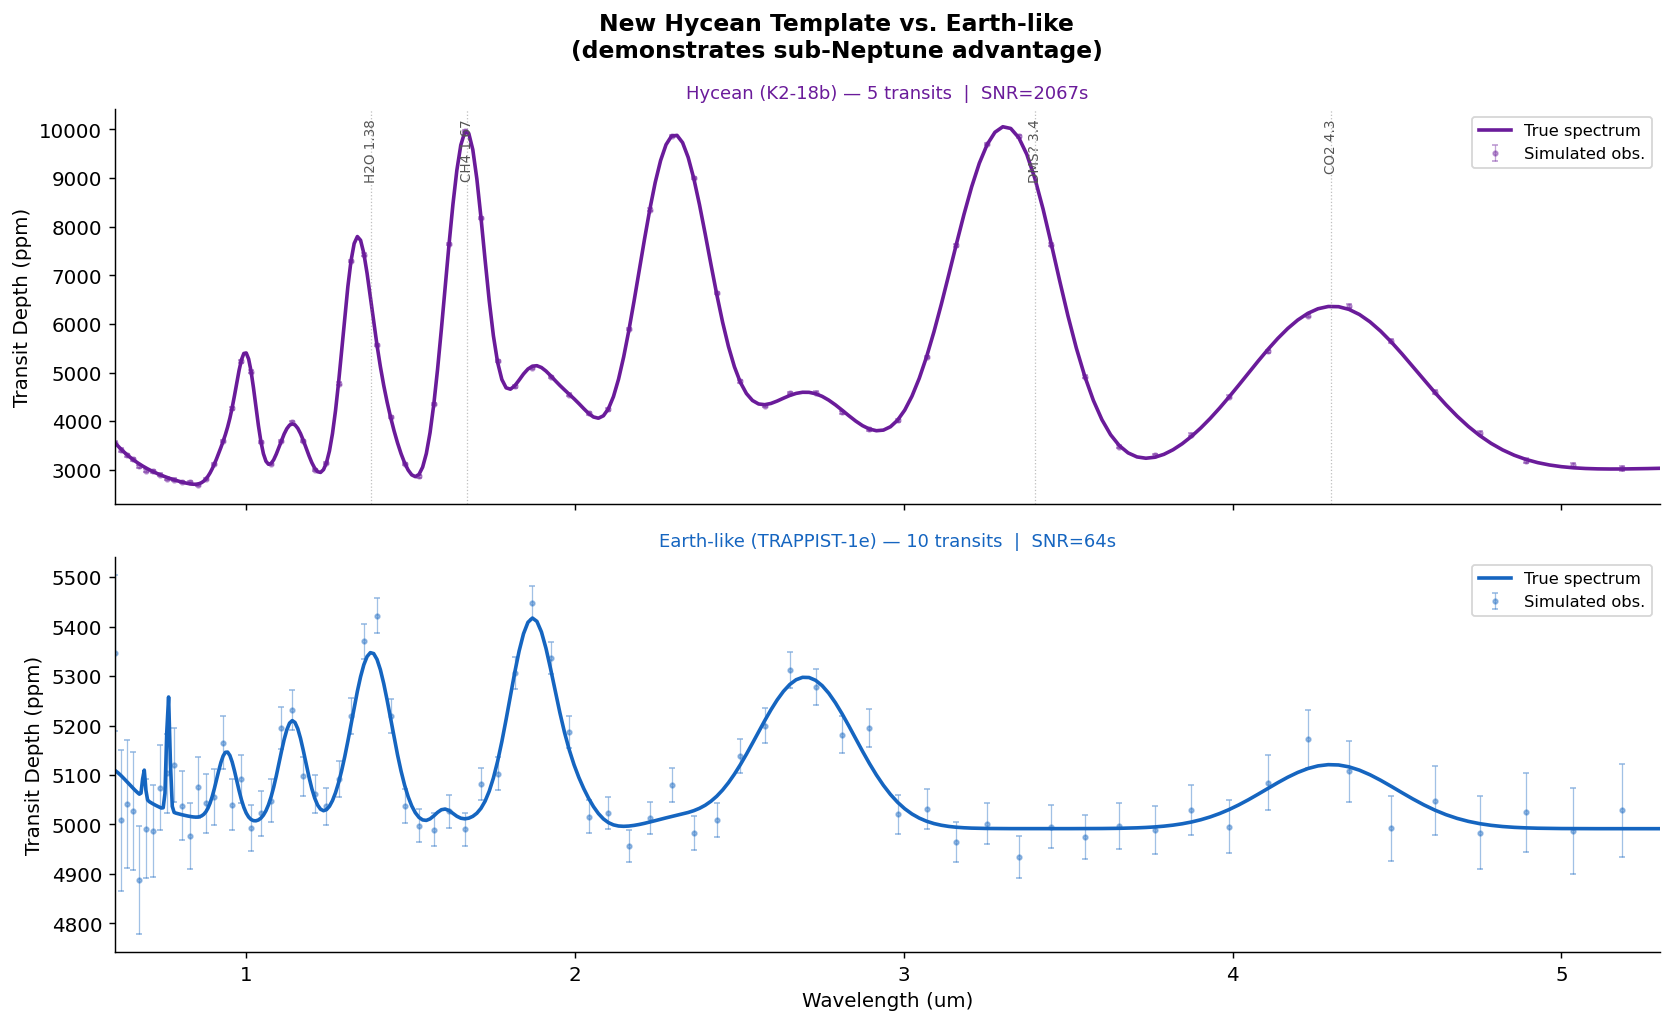

Saved results/fig08_hycean_template.png


In [6]:
from atmosphere_templates import (
    build_earth_like_template, build_hycean_template, default_wavelength_grid
)
from instrument_model import load_jwst_nirspec, load_miri_lrs
from observation_sim import ObservationSimulator, PlanetSystem

wl = default_wavelength_grid()

# K2-18b parameters for hycean
k2_18b = PlanetSystem.k2_18b()
hycean_tmpl = build_hycean_template(wl, star_radius_rs=k2_18b.star_radius_rs,
                                     planet_radius_re=k2_18b.planet_radius_re)

# Earth-like on TRAPPIST-1e for comparison
t1e = PlanetSystem.trappist1e()
earth_tmpl = build_earth_like_template(wl, star_radius_rs=t1e.star_radius_rs,
                                        planet_radius_re=t1e.planet_radius_re)

# Simulate both
jwst = load_jwst_nirspec()
sim = ObservationSimulator(jwst, rng=np.random.default_rng(7))
r_hycean = sim.simulate(k2_18b, hycean_tmpl, n_transits=5)
r_earth  = sim.simulate(t1e,    earth_tmpl,  n_transits=10)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle('New Hycean Template vs. Earth-like\n(demonstrates sub-Neptune advantage)', 
             fontsize=13, fontweight='bold')

for ax, result, color, label in [
    (axes[0], r_hycean, '#6A1B9A', f'Hycean (K2-18b) — 5 transits  |  SNR={r_hycean.detection_snr:.0f}s'),
    (axes[1], r_earth,  '#1565C0', f'Earth-like (TRAPPIST-1e) — 10 transits  |  SNR={r_earth.detection_snr:.0f}s'),
]:
    mask = (result.wavelengths_um >= 0.6) & (result.wavelengths_um <= 5.3) & (result.noise_ppm < 5000)
    wl_m = result.wavelengths_um[mask]
    ax.plot(wl_m, result.true_depth_ppm[mask], color=color, lw=2, label='True spectrum')
    ax.errorbar(wl_m[::4], result.observed_depth_ppm[mask][::4], 
                yerr=result.noise_ppm[mask][::4], fmt='o', color=color,
                alpha=0.4, ms=2.5, lw=0.7, capsize=1.5, label='Simulated obs.')
    ax.set_title(label, fontsize=10, color=color)
    ax.set_ylabel('Transit Depth (ppm)')
    ax.legend(fontsize=9)
    ax.set_xlim(0.6, 5.3)

# Annotate key hycean features
for feat, wl_c in [('CH4 1.67', 1.67), ('CO2 4.3', 4.3), ('H2O 1.38', 1.38), ('DMS? 3.4', 3.4)]:
    axes[0].axvline(wl_c, color='gray', lw=0.7, ls=':', alpha=0.5)
    axes[0].text(wl_c, axes[0].get_ylim()[1]*0.98, feat, fontsize=7.5, ha='center', 
                 va='top', color='#555', rotation=90)

axes[-1].set_xlabel('Wavelength (um)')
plt.tight_layout()
plt.savefig('results/fig08_hycean_template.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/fig08_hycean_template.png')

──────────────────────────────────────────────────
Instrument : JWST MIRI LRS
Wavelengths: 5.00 – 14.00 μm
Resolution : R = 100  (Δλ ≈ 12.5 nm at 1.25 μm)
Aperture   : 25.4 m²  (D ≈ 5.7 m effective)
Throughput : 12% peak
Read noise : 30.0 e⁻/read
Dark current: 10.000 e⁻/s/pixel
Noise floor: 50 ppm (systematic)
Notes      : MIRI LRS slitless mode. R~100, 5-14 um. Si:As IBC detector. Thermal background dominates. Ref: Kendrew+2015 PASP 127 623; Wright+2023 PASP 135 048003. Validate with JWST ETC.
──────────────────────────────────────────────────


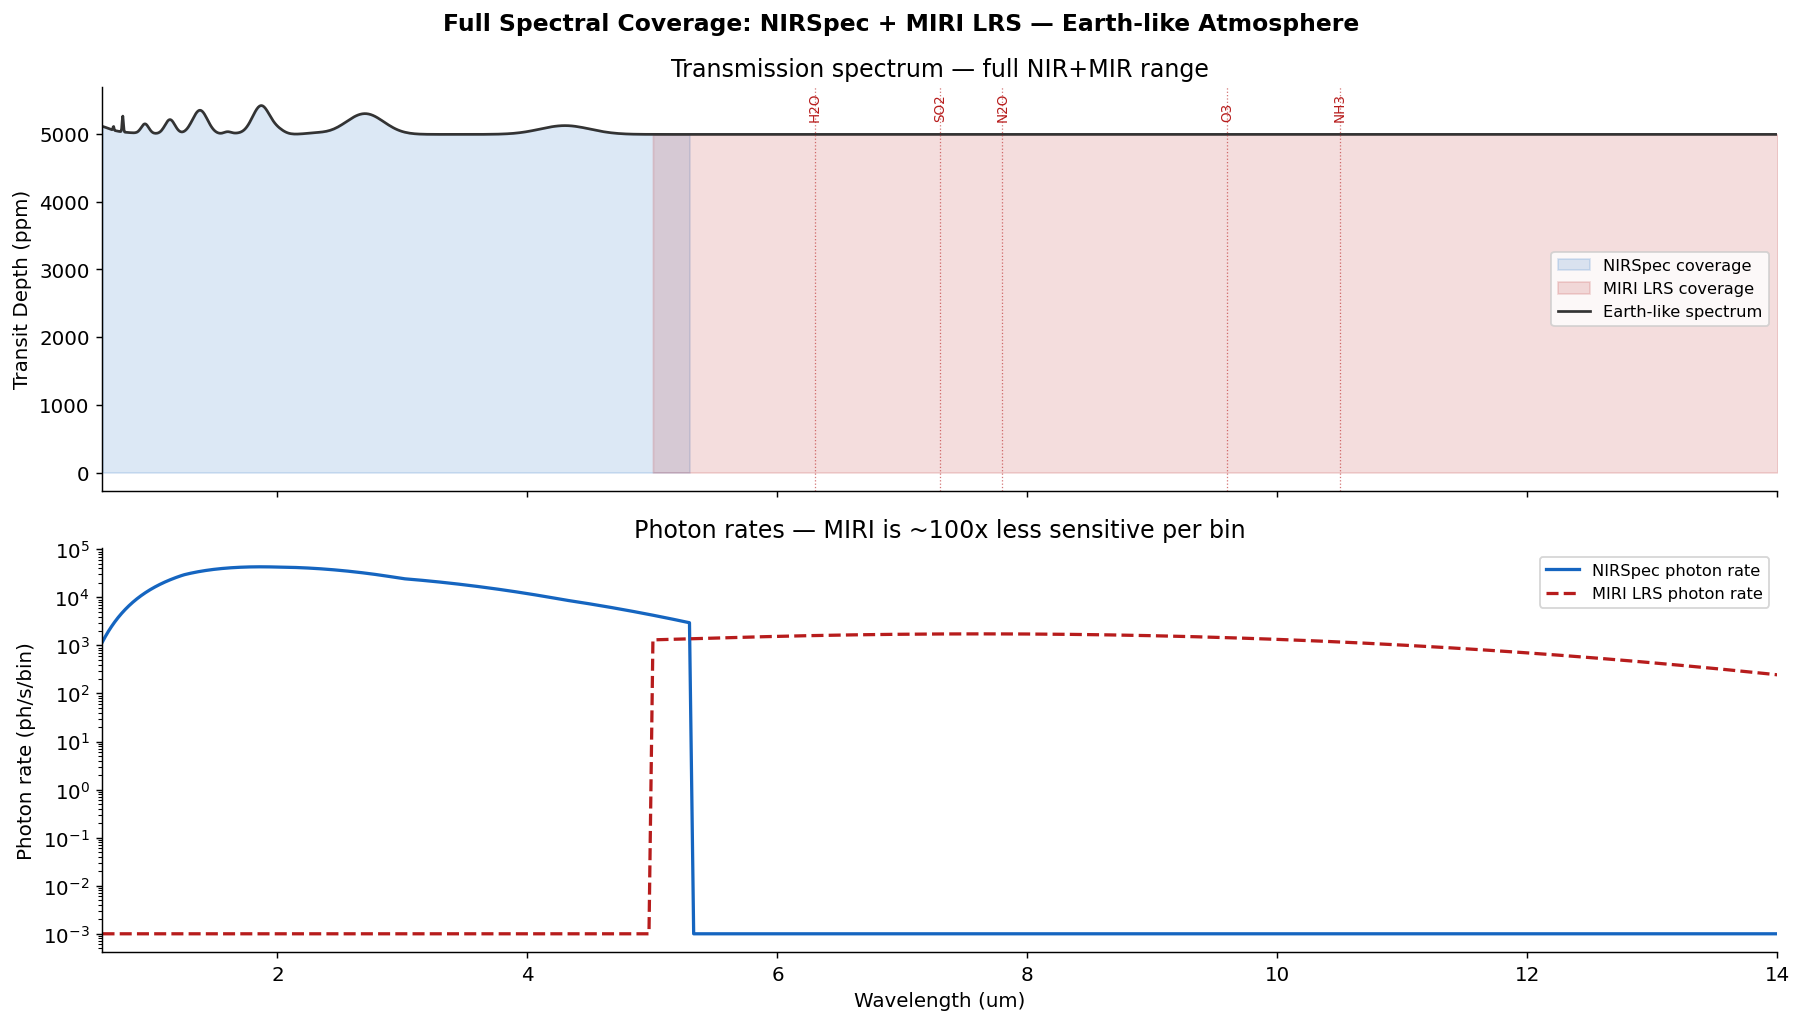

Saved results/fig09_miri_coverage.png


In [7]:
from instrument_model import load_miri_lrs
from atmosphere_templates import build_earth_like_template
import numpy as np

miri = load_miri_lrs()
print(miri.summary())

# Extended wavelength grid covering both NIRSpec and MIRI
wl_full = np.logspace(np.log10(0.6), np.log10(14.0), 500)

# Earth-like template on extended grid
earth_full = build_earth_like_template(wl_full, star_radius_rs=0.1192, planet_radius_re=0.92)

# MIRI photon rate (for context)
rate_miri = miri.stellar_photon_rate(wl_full, star_magnitude_j=11.35, star_teff_k=2566)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Full Spectral Coverage: NIRSpec + MIRI LRS — Earth-like Atmosphere',
             fontsize=13, fontweight='bold')

# NIRSpec + MIRI coverage shading
nirspec_range = (wl_full >= 0.6) & (wl_full <= 5.3)
miri_range    = (wl_full >= 5.0) & (wl_full <= 14.0)

ax = axes[0]
ax.fill_between(wl_full, 0, earth_full.transit_depth_ppm,
                where=nirspec_range, alpha=0.15, color='#1565C0', label='NIRSpec coverage')
ax.fill_between(wl_full, 0, earth_full.transit_depth_ppm,
                where=miri_range,    alpha=0.15, color='#B71C1C', label='MIRI LRS coverage')
ax.plot(wl_full, earth_full.transit_depth_ppm, color='#333', lw=1.5, label='Earth-like spectrum')

# Mid-IR biosignature annotations
mid_ir_features = [(6.3,'H2O'),(7.3,'SO2'),(7.8,'N2O'),(9.6,'O3'),(10.5,'NH3'),(15.0,'CO2*')]
for feat_wl, feat_name in mid_ir_features:
    if feat_wl <= 14.5:
        ax.axvline(feat_wl, color='#B71C1C', lw=0.7, ls=':', alpha=0.6)
        ax.text(feat_wl, ax.get_ylim()[1]*0.92 if ax.get_ylim()[1] > 0 else 
                earth_full.transit_depth_ppm.max()*0.85, 
                feat_name, fontsize=7.5, ha='center', color='#B71C1C', rotation=90)

ax.set_ylabel('Transit Depth (ppm)')
ax.set_title('Transmission spectrum — full NIR+MIR range')
ax.legend(fontsize=9)
ax.set_xlim(0.6, 14.0)

# Photon rate comparison
rate_nirspec = jwst.stellar_photon_rate(wl_full, 11.35, 2566)
axes[1].semilogy(wl_full, rate_nirspec + 1e-3, color='#1565C0', lw=1.8, label='NIRSpec photon rate')
axes[1].semilogy(wl_full, rate_miri + 1e-3,    color='#B71C1C', lw=1.8, ls='--', label='MIRI LRS photon rate')
axes[1].set_ylabel('Photon rate (ph/s/bin)')
axes[1].set_title('Photon rates — MIRI is ~100x less sensitive per bin')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0.6, 14.0)

axes[-1].set_xlabel('Wavelength (um)')
plt.tight_layout()
plt.savefig('results/fig09_miri_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/fig09_miri_coverage.png')